# **Text Classification using RNN**

### 1. Exploratory Data Analysis (EDA)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.preprocessing import MinMaxScaler
import keras
import tensorflow as tf
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
df=pd.read_csv('monthly_milk_production.csv',index_col='Date',parse_dates=True)
df.head()

,Production
Date,
1962-01-01,589
1962-02-01,561
1962-03-01,640
1962-04-01,656
1962-05-01,727


In [3]:
df.shape

(168, 1)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 168 entries, 1962-01-01 to 1975-12-01
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Production  168 non-null    int64
dtypes: int64(1)
memory usage: 2.6 KB


In [5]:
df.describe()

,Production
count,168.000000
mean,754.708333
std,102.204524
min,553.000000
25%,677.750000
50%,761.000000
75%,824.500000
max,969.000000


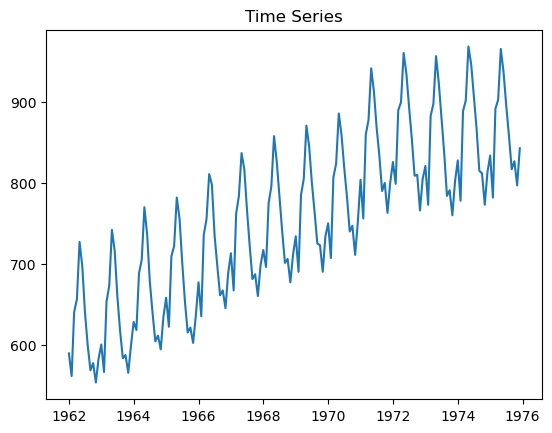

In [6]:
plt.plot(df)
plt.title('Time Series')
plt.show()

<Axes: title={'center': 'Trend'}, xlabel='Date'>

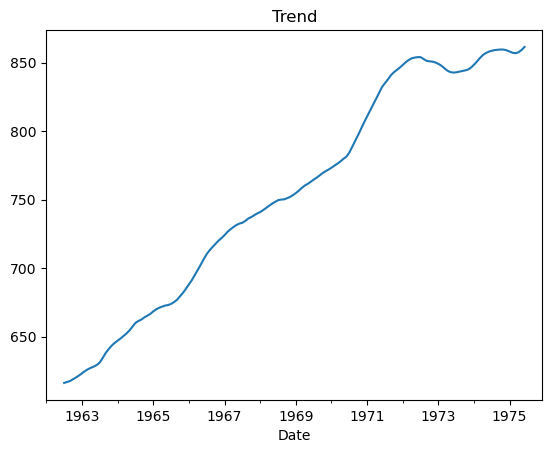

In [7]:
result=seasonal_decompose(df['Production'],model='multiplicative')
plt.title('Trend')
result.trend.plot()

Text(0.5, 1.0, 'Sesonal')

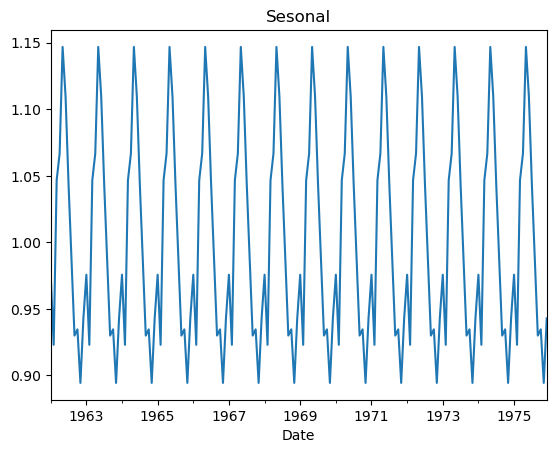

In [8]:
result.seasonal.plot()
plt.title('Sesonal')

Text(0.5, 1.0, 'Residual')

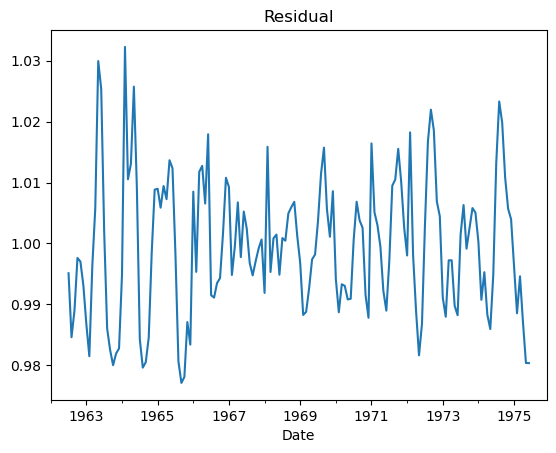

In [9]:
result.resid.plot()
plt.title('Residual')

<Axes: >

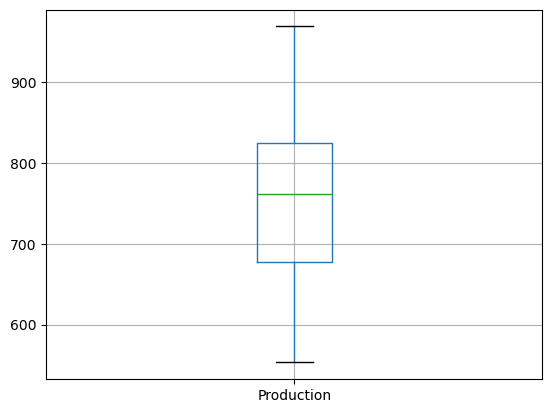

In [10]:
df.boxplot()

In [11]:
## missing values
df.isnull().sum()

Production    0
dtype: int64

In [12]:
## duplicates
df.duplicated().sum()

np.int64(26)

In [13]:
## drop dupllicates
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [14]:
## Min Max Scaling
min_max=MinMaxScaler()
df1=min_max.fit_transform(df[['Production']])

### 2. Data Preparation for Deep Learning

In [15]:
## input output sequ
window_size=12
def in_op_seq(df1,window_size):
    x=[]
    y=[]
    for i in range(window_size,len(df1)):
            x.append(df1[i-window_size:i,0])
            y.append(df1[i,0])
    return np.array(x), np.array(y)

In [16]:
## train,val,test split
train_size = int(len(df1) * 0.70)
val_size   = int(len(df1) * 0.15)

In [17]:
train = df1[:train_size]
val   = df1[train_size : train_size + val_size]
test  = df1[train_size + val_size:]

In [18]:
# Create sequences for each split
x_train, y_train = in_op_seq(train, window_size)
x_val,   y_val   = in_op_seq(val, window_size)
x_test,  y_test  = in_op_seq(test, window_size)

In [19]:
## reshape data
x_train = x_train.reshape(x_train.shape[0], x_train.shape[1], 1)
x_val   = x_val.reshape(x_val.shape[0],   x_val.shape[1],   1)
x_test  = x_test.reshape(x_test.shape[0], x_test.shape[1],  1)
print("Training shape :", x_train.shape, y_train.shape)
print("Validation shape:", x_val.shape, y_val.shape)
print("Test shape:", x_test.shape, y_test.shape)

Training shape : (87, 12, 1) (87,)
Validation shape: (9, 12, 1) (9,)
Test shape: (10, 12, 1) (10,)


### 3. Model Building

##### Basic RNN

In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

In [21]:
##params
params = {'window_size': [6, 12],'units': [32, 64],'batch_size': [8, 16],
    'epochs': [30, 50]}

In [22]:
best_loss = float('inf')
best_params = {}

In [23]:
## hyperparameter tuning
for w in params['window_size']:
    x_train_w, y_train_w = in_op_seq(train, w)
    x_val_w, y_val_w     = in_op_seq(val, w)
    x_train_w = x_train_w.reshape(x_train_w.shape[0], w, 1)
    x_val_w   = x_val_w.reshape(x_val_w.shape[0], w, 1)
    for u in params['units']:
        for b in params['batch_size']:
            for e in params['epochs']:
                print(f"Training RNN → window={w}, units={u}, batch={b}, epochs={e}")
                model = Sequential([
                    SimpleRNN(u, input_shape=(w,1)),
                    Dense(1)])
                model.compile(optimizer='adam', loss='mse')
                history = model.fit(x_train_w, y_train_w,batch_size=b,epochs=e,
                    validation_data=(x_val_w, y_val_w),verbose=0)
                if 'val_loss' not in history.history:
                          print(f" validation loss for window size={w}, units={u}, batch={b}, epochs={e}")
                          continue

                val_loss = history.history['val_loss'][-1]

                if val_loss < best_loss:
                    best_loss = val_loss
                    best_params = {'window_size': w,'units': u,'batch_size': b,
                        'epochs': e}

Training RNN → window=6, units=32, batch=8, epochs=30
Training RNN → window=6, units=32, batch=8, epochs=50
Training RNN → window=6, units=32, batch=16, epochs=30
Training RNN → window=6, units=32, batch=16, epochs=50
Training RNN → window=6, units=64, batch=8, epochs=30
Training RNN → window=6, units=64, batch=8, epochs=50
Training RNN → window=6, units=64, batch=16, epochs=30
Training RNN → window=6, units=64, batch=16, epochs=50
Training RNN → window=12, units=32, batch=8, epochs=30
Training RNN → window=12, units=32, batch=8, epochs=50
Training RNN → window=12, units=32, batch=16, epochs=30
Training RNN → window=12, units=32, batch=16, epochs=50
Training RNN → window=12, units=64, batch=8, epochs=30
Training RNN → window=12, units=64, batch=8, epochs=50
Training RNN → window=12, units=64, batch=16, epochs=30
Training RNN → window=12, units=64, batch=16, epochs=50


In [24]:
print('\nBest Hyperparameters',best_params)
print('Best Validation Loss:', best_loss)


Best Hyperparameters {'window_size': 12, 'units': 64, 'batch_size': 16, 'epochs': 30}
Best Validation Loss: 0.004716690629720688


In [25]:
## model building
rnn=tf.keras.models.Sequential()
rnn.add(tf.keras.layers.SimpleRNN(units=64,activation='tanh',input_shape=[12,1]))
rnn.add(tf.keras.layers.Dense(units=1))
rnn.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn_16 (SimpleRNN)            │ (None, 64)                  │           4,224 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,289 (16.75 KB)

 Trainable params: 4,289 (16.75 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
### model compile
rnn.compile(optimizer=tf.keras.optimizers.Adam(),loss=tf.keras.losses.mse)

In [27]:
### model training
history_rnn=rnn.fit(x_train,y_train,epochs=30,batch_size=8,validation_data=(x_val, y_val))

Epoch 1/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - loss: 0.0888 - val_loss: 0.0887
Epoch 2/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0288 - val_loss: 0.0058
Epoch 3/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0183 - val_loss: 0.0112
Epoch 4/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0137 - val_loss: 0.0091
Epoch 5/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0121 - val_loss: 0.0071
Epoch 6/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0115 - val_loss: 0.0071
Epoch 7/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0108 - val_loss: 0.0068
Epoch 8/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0109 - val_loss: 0.0079
Epoch 9/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0108 - val_loss: 0.0079
Epoch 10/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0106 - val_loss: 0.0068
Epoch 11/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0101 - val_loss: 0.0075
Epoch 12/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0

In [28]:
## model testing
pred_rnn=rnn.predict(x_test)
y_pred_rnn=min_max.inverse_transform(pred_rnn)
y_test_rnn=min_max.inverse_transform(y_test.reshape(-1,1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step


##### LSTM

In [29]:
from tensorflow.keras.layers import LSTM

In [30]:
best_loss_lstm = float('inf')
best_params_lstm = {}

In [31]:
## hyperparameter tuning
for w in params['window_size']:
    x_train_w, y_train_w = in_op_seq(train, w)
    x_val_w, y_val_w     = in_op_seq(val, w)
    if x_val_w.shape[0] == 0:
        print(f"Skipping window_size {w}: Validation sequences empty")
        continue
    x_train_w = x_train_w.reshape(x_train_w.shape[0], w, 1)
    x_val_w   = x_val_w.reshape(x_val_w.shape[0], w, 1)
    for u in params['units']:
        for b in params['batch_size']:
            for e in params['epochs']:
                print(f"Training LSTM → window={w}, units={u}, batch={b}, epochs={e}")
                model = Sequential([
                    LSTM(u, input_shape=(w,1)),
                    Dense(1)])
                model.compile(optimizer='adam', loss='mse')
                history = model.fit(x_train_w, y_train_w,batch_size=b,epochs=e,
                    validation_data=(x_val_w, y_val_w),verbose=0)
                if 'val_loss' not in history.history:
                          print(f" validation loss for window size={w}, units={u}, batch={b}, epochs={e}")
                          continue

                val_loss = history.history['val_loss'][-1]

                if val_loss< best_loss_lstm:
                    best_loss_lstm = val_loss
                    best_params_lstm = {'window_size': w,'units': u,'batch_size': b,
                        'epochs': e}

Training LSTM → window=6, units=32, batch=8, epochs=30
Training LSTM → window=6, units=32, batch=8, epochs=50
Training LSTM → window=6, units=32, batch=16, epochs=30
Training LSTM → window=6, units=32, batch=16, epochs=50
Training LSTM → window=6, units=64, batch=8, epochs=30
Training LSTM → window=6, units=64, batch=8, epochs=50
Training LSTM → window=6, units=64, batch=16, epochs=30
Training LSTM → window=6, units=64, batch=16, epochs=50
Training LSTM → window=12, units=32, batch=8, epochs=30
Training LSTM → window=12, units=32, batch=8, epochs=50
Training LSTM → window=12, units=32, batch=16, epochs=30
Training LSTM → window=12, units=32, batch=16, epochs=50
Training LSTM → window=12, units=64, batch=8, epochs=30
Training LSTM → window=12, units=64, batch=8, epochs=50
Training LSTM → window=12, units=64, batch=16, epochs=30
Training LSTM → window=12, units=64, batch=16, epochs=50


In [32]:
print('\nBest Hyperparameters',best_params_lstm)
print('Best Validation Loss:', best_loss_lstm)


Best Hyperparameters {'window_size': 12, 'units': 32, 'batch_size': 8, 'epochs': 50}
Best Validation Loss: 0.006384726148098707


In [33]:
## model building
lstm=tf.keras.models.Sequential()
lstm.add(tf.keras.layers.LSTM(units=64,input_shape=[12,1]))
lstm.add(tf.keras.layers.Dropout(0.2))
lstm.add(tf.keras.layers.Dense(units=1))
lstm.summary()

Model: "sequential_33"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_16 (LSTM)                       │ (None, 64)                  │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_33 (Dense)                     │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
### model compile
lstm.compile(optimizer=tf.keras.optimizers.Adam(),loss=tf.keras.losses.mse)

In [35]:
### model training
history_lstm=lstm.fit(x_train,y_train,epochs=50,batch_size=16,validation_data=(x_val, y_val))

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 134ms/step - loss: 0.1629 - val_loss: 0.1879
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0514 - val_loss: 0.0256
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0338 - val_loss: 0.0411
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0317 - val_loss: 0.0268
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0250 - val_loss: 0.0378
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0286 - val_loss: 0.0360
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0292 - val_loss: 0.0278
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0246 - val_loss: 0.0266
Epoch 9/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0275 - val_loss: 0.0257
Epoch 10/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0265 - val_loss: 0.0264
Epoch 11/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0234 - val_loss: 0.0253
Epoch 12/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0222 - val_loss: 0.0249


In [36]:
## model testing
pred_lstm=lstm.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step


In [37]:
pred_lstm = pred_lstm.reshape(-1, 1)
y_pred_lstm=min_max.inverse_transform(pred_lstm)
y_test_lstm=min_max.inverse_transform(y_test.reshape(-1,1))

##### GRU

In [38]:
from tensorflow.keras.layers import GRU

In [39]:
best_loss_gru = float('inf')
best_params_gru = {}

In [40]:
## hyperparameter tuning
for w in params['window_size']:
    x_train_w, y_train_w = in_op_seq(train, w)
    x_val_w, y_val_w     = in_op_seq(val, w)
    if x_val_w.shape[0] == 0:
        print(f"Skipping window_size {w}: Validation sequences empty")
        continue
    x_train_w = x_train_w.reshape(x_train_w.shape[0], w, 1)
    x_val_w   = x_val_w.reshape(x_val_w.shape[0], w, 1)
    for u in params['units']:
        for b in params['batch_size']:
            for e in params['epochs']:
                print(f"Training GRU → window={w}, units={u}, batch={b}, epochs={e}")
                model = Sequential([
                    GRU(u, input_shape=(w,1)),
                    Dense(1)])
                model.compile(optimizer='adam', loss='mse')
                history = model.fit(x_train_w, y_train_w,batch_size=b,epochs=e,
                    validation_data=(x_val_w, y_val_w),verbose=0)
                if 'val_loss' not in history.history:
                          print(f" validation loss for window size={w}, units={u}, batch={b}, epochs={e}")
                          continue

                val_loss = history.history['val_loss'][-1]

                if val_loss< best_loss_gru:
                    best_loss_gru = val_loss
                    best_params_gru = {'window_size': w,'units': u,'batch_size': b,
                        'epochs': e}

Training GRU → window=6, units=32, batch=8, epochs=30
Training GRU → window=6, units=32, batch=8, epochs=50
Training GRU → window=6, units=32, batch=16, epochs=30
Training GRU → window=6, units=32, batch=16, epochs=50
Training GRU → window=6, units=64, batch=8, epochs=30
Training GRU → window=6, units=64, batch=8, epochs=50
Training GRU → window=6, units=64, batch=16, epochs=30
Training GRU → window=6, units=64, batch=16, epochs=50
Training GRU → window=12, units=32, batch=8, epochs=30
Training GRU → window=12, units=32, batch=8, epochs=50
Training GRU → window=12, units=32, batch=16, epochs=30
Training GRU → window=12, units=32, batch=16, epochs=50
Training GRU → window=12, units=64, batch=8, epochs=30
Training GRU → window=12, units=64, batch=8, epochs=50
Training GRU → window=12, units=64, batch=16, epochs=30
Training GRU → window=12, units=64, batch=16, epochs=50


In [41]:
print('\nBest Hyperparameters',best_params_gru)
print('Best Validation Loss:', best_loss_gru)


Best Hyperparameters {'window_size': 12, 'units': 64, 'batch_size': 16, 'epochs': 50}
Best Validation Loss: 0.007574889343231916


In [42]:
## model building
gru=tf.keras.models.Sequential()
gru.add(tf.keras.layers.GRU(units=64,input_shape=[12,1]))
gru.add(tf.keras.layers.Dropout(0.2))
gru.add(tf.keras.layers.Dense(units=1))
gru.summary()

Model: "sequential_50"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru_16 (GRU)                         │ (None, 64)                  │          12,864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_50 (Dense)                     │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,929 (50.50 KB)

 Trainable params: 12,929 (50.50 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
### model compile
gru.compile(optimizer=tf.keras.optimizers.Adam(),loss=tf.keras.losses.mse)

In [44]:
### model training
history_gru=gru.fit(x_train,y_train,epochs=30,batch_size=8,validation_data=(x_val, y_val))

Epoch 1/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 93ms/step - loss: 0.1504 - val_loss: 0.1274
Epoch 2/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0368 - val_loss: 0.0296
Epoch 3/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0426 - val_loss: 0.0394
Epoch 4/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0326 - val_loss: 0.0565
Epoch 5/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0304 - val_loss: 0.0420
Epoch 6/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0313 - val_loss: 0.0377
Epoch 7/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0299 - val_loss: 0.0378
Epoch 8/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0289 - val_loss: 0.0323
Epoch 9/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0278 - val_loss: 0.0388
Epoch 10/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0248 - val_loss: 0.0302
Epoch 11/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0247 - val_loss: 0.0313
Epoch 12/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0

In [45]:
## model testing
pred_gru=gru.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 504ms/step


In [46]:
pred_gru = pred_gru.reshape(-1, 1)
y_pred_gru=min_max.inverse_transform(pred_gru)
y_test_gru=min_max.inverse_transform(y_test.reshape(-1,1))

### 4. Model Evaluation

##### RNN

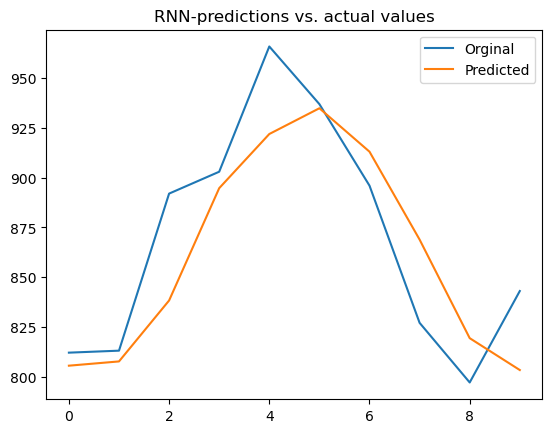

In [47]:
## plot actual-pred
plt.plot(y_test_rnn,label='Orginal')
plt.plot(y_pred_rnn,label='Predicted')
plt.title('RNN-predictions vs. actual values')
plt.legend()

In [48]:
## Evaluation metrics
rmse_rnn = np.sqrt(mean_squared_error(y_test_rnn, y_pred_rnn))
mae_rnn  = mean_absolute_error(y_test_rnn, y_pred_rnn)
mape_rnn = np.mean(np.abs((y_test_rnn - y_pred_rnn) / y_test_rnn)) * 100
print("RNN RMSE:", rmse_rnn)
print("RNN MAE :", mae_rnn)
print("RNN MAPE:", mape_rnn)

RNN RMSE: 30.157929262388073
RNN MAE : 24.108166503906215
RNN MAPE: 2.7674979519589455


##### LSTM

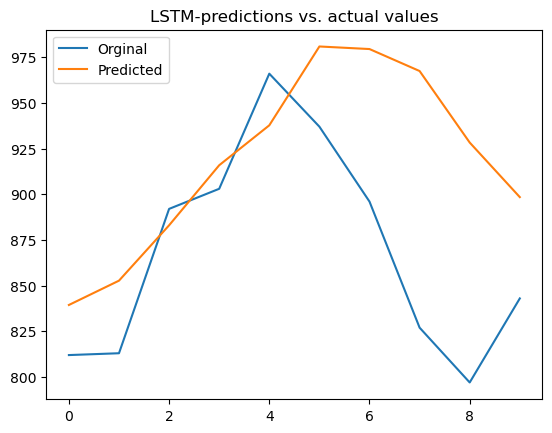

In [49]:
## plot actual-pred
plt.plot(y_test_lstm,label='Orginal')
plt.plot(y_pred_lstm,label='Predicted')
plt.title('LSTM-predictions vs. actual values')
plt.legend()

In [50]:
## Evaluation metrics
rmse_lstm = np.sqrt(mean_squared_error(y_test_lstm, y_pred_lstm))
mae_lstm  = mean_absolute_error(y_test_lstm, y_pred_lstm)
mape_lstm = np.mean(np.abs((y_test_lstm - y_pred_lstm) / y_test_lstm)) * 100
print("LSTM RMSE:", rmse_lstm)
print("LSTM MAE :", mae_lstm)
print("LSTM MAPE:", mape_lstm)

LSTM RMSE: 72.32575946871431
LSTM MAE : 57.18191528320309
LSTM MAPE: 6.765595428518259


##### GRU

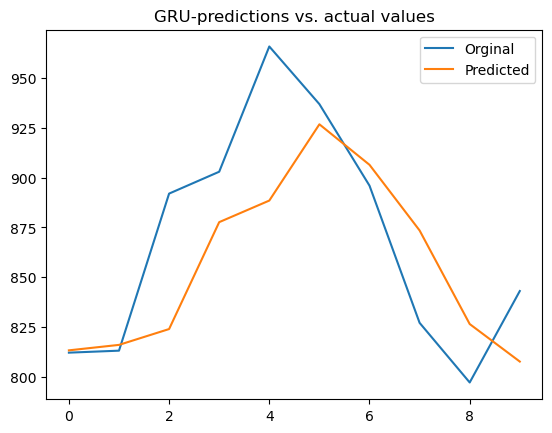

In [51]:
## plot actual-pred
plt.plot(y_test_gru,label='Orginal')
plt.plot(y_pred_gru,label='Predicted')
plt.title('GRU-predictions vs. actual values')
plt.legend()

In [52]:
## Evaluation metrics
rmse_gru = np.sqrt(mean_squared_error(y_test_gru, y_pred_gru))
mae_gru  = mean_absolute_error(y_test_gru, y_pred_gru)
mape_gru = np.mean(np.abs((y_test_gru - y_pred_gru) / y_test_gru)) * 100
print("GRU RMSE:", rmse_gru)
print("GRU MAE :", mae_gru)
print("GRU MAPE:", mape_gru)

GRU RMSE: 39.74331526722949
GRU MAE : 30.70260620117184
GRU MAPE: 3.4737738613814115


### 5. Prediction and Visualization

In [53]:
from pandas.tseries.offsets import MonthBegin

In [54]:
## 12 month forecasting
w = window_size          
last_window = df1[-w:]  
cur = last_window.reshape(1, w, 1)
n_months = 12

In [55]:
preds_scaled=[]
for i in range(n_months):
    p=rnn.predict(cur,verbose=0)
    p=p.reshape(1,1)
    preds_scaled.append(p[0,0])
    cur=np.concatenate([cur[:,1:,:],p.reshape(1,1,1)],axis=1)
preds_scaled=np.array(preds_scaled).reshape(-1,1)
preds=min_max.inverse_transform(preds_scaled).flatten()

In [56]:
##Create future dates
future_idx = pd.date_range(start=df.index[-1] + MonthBegin(1), periods=n_months,
    freq='MS')
forecast_series = pd.Series(preds, index=future_idx)
print("Next 12 Months Forecast:\n")
print(forecast_series)

Next 12 Months Forecast:

1976-01-01    844.054382
1976-02-01    878.754272
1976-03-01    886.820862
1976-04-01    893.248047
1976-05-01    902.402649
1976-06-01    890.007874
1976-07-01    874.194641
1976-08-01    852.280396
1976-09-01    842.640869
1976-10-01    842.615967
1976-11-01    851.796631
1976-12-01    869.864746
Freq: MS, dtype: float32


In [57]:
## Compute Confidence Interval
residuals = (y_test_rnn.flatten() - y_pred_rnn.flatten())
res_std = residuals.std()
ci_upper = preds + 1.96 * res_std
ci_lower = preds - 1.96 * res_std

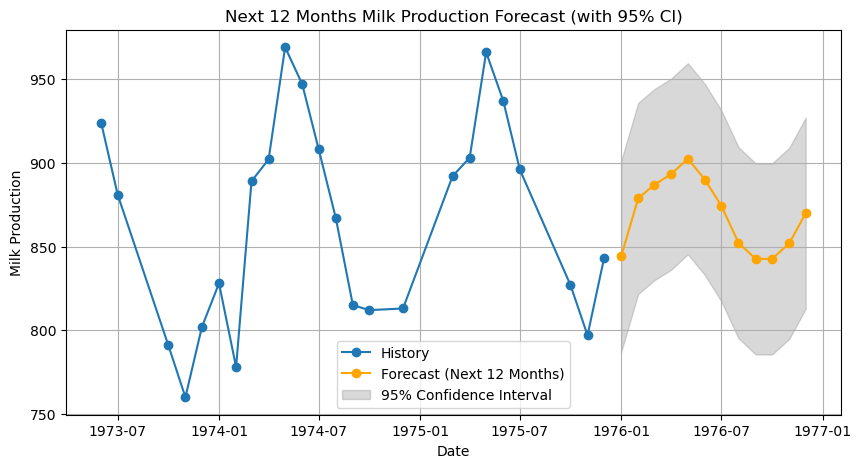

In [58]:
# plot forecast
plt.figure(figsize=(10,5))
# last 24 months history
plt.plot(df.index[-24:], df['Production'].values[-24:], marker='o', label="History")
# forecast line
plt.plot(future_idx, preds, marker='o', color='orange', label="Forecast (Next 12 Months)")
# confidence interval shading
plt.fill_between(future_idx, ci_lower, ci_upper, color='gray', alpha=0.3, label="95% Confidence Interval")
plt.title("Next 12 Months Milk Production Forecast (with 95% CI)")
plt.xlabel("Date")
plt.ylabel("Milk Production")
plt.grid(True)
plt.legend()
plt.show()

### 6. Business Insights